In [95]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('dark_background')


# P395: Guide 6 — Linear Algebra

This week we focus on solving various problems from **linear algebra**. Most boil down to solving a system of linear equations for unknown variables, conveniently written in matrix form as $\mathbf{A}\mathbf{x} = \mathbf{b}$, where each row of $A$ is one equation, $\mathbf{x}$ is the vector of unknowns, and $\mathbf{b}$ is a vector of constants. Python has many optimized routines for this.


## Task 1:

In [96]:
# 1.  

a = [1.1, -2.1, 0.0]
b = [2.0,  1.1, -0.5]


list_result = a + b
print(f"List Addition: {list_result}")

a, b = np.array(a),np.array(b)
np_result = a + b
print(f"Numpy Array Addition: {np_result}")




List Addition: [1.1, -2.1, 0.0, 2.0, 1.1, -0.5]
Numpy Array Addition: [ 3.1 -1.  -0.5]


Reminder: Normal List addition just concatenates for the addition symbol, like append

Numpy array does Vector element to element addition. 

In [97]:
#2. 


scalar = 2
a = list(a)
list_scalar = scalar * a
print('List scalar', list_scalar)

a = np.array(a)
np_scalar = 2.3 * a
print('NumPy scalar', np_scalar)

List scalar [np.float64(1.1), np.float64(-2.1), np.float64(0.0), np.float64(1.1), np.float64(-2.1), np.float64(0.0)]
NumPy scalar [ 2.53 -4.83  0.  ]


**Reminder Note:**

Normal List * scalar is a repeat of the list

Numpy List * scalar gives the vector multiplication

In [98]:
# 3.  


elementwise = a * b
print('a * b:', elementwise)

a * b: [ 2.2  -2.31 -0.  ]


Reminder Note:

Numpy a*b is element wise multiplication

### Dot Product


In [99]:
# 4. 

dot_ab = a @ b
print('a dot b:', dot_ab)

a dot b: -0.11000000000000032


In [100]:
# 5. 


dot_verify = np.sum(a * b)
print('np.sum(a*b):', dot_verify)

np.sum(a*b): -0.11000000000000032


Yes both a @ b and `np.sum(a*b)` agree

In [101]:
# 6. 

cross_ab = np.cross(a, b)
print('a x b (np.cross):', cross_ab)

a x b (np.cross): [1.05 0.55 5.41]


#### 7. Analysis: 

With $\mathbf{a} = (1.1, -2.1, 0.0)$ and $\mathbf{b} = (2.0, 1.1, -0.5)$:

- $\hat{i}:(-2.1)(-0.5) - (0.0)(1.1) = 1.05$
- $\hat{j}: -[(1.1)(-0.5) - (0.0)(2.0)] = 0.55$
- $\hat{k}: (1.1)(1.1) - (-2.1)(2.0) = 1.21 + 4.20 = 5.41$

*ANS:* Yes Matches

### Vector Norm

In [102]:
# 8. 
import scipy.linalg as la

In [103]:
# 9. 

norm_la  = la.norm(a)
norm_dot = np.sqrt(a@ a)
print('la.norm(a)  :', norm_la)
print('sqrt(a·a)   :', norm_dot)

la.norm(a)  : 2.3706539182259396
sqrt(a·a)   : 2.3706539182259396


yes la.norm(a) and sqrt(a dot a) agree

### Task 2: Matrices and 2D Arrays


In [104]:
# 1. 
# Like Pauli Matrices we find in QM

sigma_x = np.array([[0, 1],
                    [1, 0]])
sigma_z = np.array([[1,  0],
                    [0, -1]])


In [105]:
mat_prod = np.dot(sigma_x, sigma_z)
print(mat_prod)

[[ 0 -1]
 [ 1  0]]


In [106]:
# 3. 

elementwise_2d = sigma_x * sigma_z
print( elementwise_2d)

[[0 0]
 [0 0]]


Not what we found in 2.

In [107]:
# 4. 

triple =  np.dot(sigma_x, sigma_z,sigma_z)
print(triple)

[[ 0 -1]
 [ 1  0]]


In [108]:
# 5. 

zeros_3x4 = np.zeros((3, 4))
print(zeros_3x4)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [109]:
# 6. 
identity_5 = np.identity(5)
print(identity_5)

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [110]:
# 7. 

M = np.random.random((3, 3))
print('Random 3x3 matrix M:')
print(M)

Random 3x3 matrix M:
[[0.15097327 0.80306975 0.54805003]
 [0.25098981 0.9086098  0.8962274 ]
 [0.32529394 0.19323167 0.99542765]]


In [111]:
# 8. 

M_T = M.T
print( M_T)

[[0.15097327 0.25098981 0.32529394]
 [0.80306975 0.9086098  0.19323167]
 [0.54805003 0.8962274  0.99542765]]


In [112]:
# 9.  

M_inv = la.inv(M)
print(M_inv)

[[ 86.20853646 -81.75489935  26.14392994]
 [  4.91535167  -3.30019811   0.26508142]
 [-29.1260912   27.35716304  -7.59039015]]


In [113]:
# 10. 

product = np.dot(M_inv, M)
print(product)


[[ 1.00000000e+00  2.44843900e-15  3.63856400e-15]
 [ 1.37865735e-16  1.00000000e+00  3.36117210e-16]
 [-5.47814194e-16  5.72263582e-16  1.00000000e+00]]


This in fact is the idenity matrix, its just that there is a rounding error. On the Diagonal we have 1's and 0/ almost zero numbers on the off diagonals. 

Note: Today I learnt that there is such a thing called an Under flow. 

### Task 3: LU Decomposition

### Background: Solving Linear Systems

To solve $A\mathbf{x} = \mathbf{b}$, Python uses **LU decomposition** rather than computing A^-1 explicitly (numerically unstable for some matrices). 

You find Lower and Upper matrices (LU) such that A = LU and then solve two equations. 
This is how `la.solve(A, b)` does it internally.


In [114]:
#1. 


A5 = np.random.random((5, 5))
b5 = np.random.random(5)
print("Matrix A =",A5)
print('b =', b5)

Matrix A = [[0.84671338 0.08317308 0.96516523 0.14651745 0.12261747]
 [0.81348595 0.15285688 0.00263163 0.93376599 0.781993  ]
 [0.77537171 0.23709977 0.34668765 0.35444957 0.46853948]
 [0.51879606 0.68236181 0.70537254 0.02043178 0.92577968]
 [0.24491927 0.05455007 0.69660191 0.0541492  0.87892237]]
b = [0.62534494 0.94480271 0.4275081  0.15044156 0.35320862]


In [115]:
# 2. 


x5 = la.solve(A5, b5)
print('Solution x =', x5)

Solution x = [-0.26068467 -0.13282696  0.69696084  1.3886687  -0.15518836]


In [116]:
# 3. 


b_check = np.dot(A5, x5)
print('A dot x =',b_check)

A dot x = [0.62534494 0.94480271 0.4275081  0.15044156 0.35320862]


Yes the dot A and Sol x is infact the original B. 

Ask: Why?

In [117]:
# 4. 

P5, L5, U5 = la.lu(A5)
print('Permutation P:\n', P5)
print('Lower L:\n',L5)
print('Upper U:\n', U5)

Permutation P:
 [[1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]
Lower L:
 [[ 1.          0.          0.          0.          0.        ]
 [ 0.61271745  1.          0.          0.          0.        ]
 [ 0.96075717  0.1155333   1.          0.          0.        ]
 [ 0.28925876  0.04829191 -0.43922124  1.          0.        ]
 [ 0.91574284  0.25488527  0.6037481  -0.66947901  1.        ]]
Upper U:
 [[ 0.84671338  0.08317308  0.96516523  0.14651745  0.12261747]
 [ 0.          0.63140021  0.11399896 -0.06934201  0.85064982]
 [ 0.          0.         -0.93782846  0.80100962  0.56590901]
 [ 0.          0.          0.          0.36693684  1.05093394]
 [ 0.          0.          0.          0.          0.50134703]]


In [118]:
# 5. 

PLU = P5 @ L5 @ U5 # Same as np.dot(P5, np.dot(L5,U5))
print(PLU)
print('PLU =', np.allclose(PLU, A5)) # A Way to check if two objects are near each other with some tolerance

[[0.84671338 0.08317308 0.96516523 0.14651745 0.12261747]
 [0.81348595 0.15285688 0.00263163 0.93376599 0.781993  ]
 [0.77537171 0.23709977 0.34668765 0.35444957 0.46853948]
 [0.51879606 0.68236181 0.70537254 0.02043178 0.92577968]
 [0.24491927 0.05455007 0.69660191 0.0541492  0.87892237]]
PLU = True


In [119]:
# 6.

# Using L and U to manually solve Ax = b in two triangular steps
# Since la.lu gives P, L, U such that A = P @ L @ U, we need:
#   L(Ux) = P^{-1} b = P^T b   (P is orthogonal so P^{-1} = P^T)

# Step i: Compute b' = P^T @ b  (apply inverse permutation)
b_prime = P5.T @ b5

# Step ii: Forward substitution — solve Ly = b'
y = la.solve_triangular(L5, b_prime, lower=True)

# Step iii: Back substitution — solve Ux = y
x_lu = la.solve_triangular(U5, y)

print('x from LU forward/back sub:', x_lu)
print('x from la.solve:            ', x5)
print('Agree?', np.allclose(x_lu, x5))

x from LU forward/back sub: [-0.26068467 -0.13282696  0.69696084  1.3886687  -0.15518836]
x from la.solve:             [-0.26068467 -0.13282696  0.69696084  1.3886687  -0.15518836]
Agree? True


#### 7. Analysis: Is x from (6) the same as in (2)?

*ANS:* Yes — `x_lu` from the manual LU forward/back substitution agrees with `x5` from `la.solve` to machine precision (`np.allclose` returns `True`).

This confirms what `la.solve` does internally:
1. Perform LU decomposition with partial pivoting: $A = PLU$
2. Apply the inverse permutation: $b' = P^{-1}b = P^T b$
3. Forward substitution to solve $Ly = b'$
4. Back substitution to solve $Ux = y$

Doing it this way avoids computing $A^{-1}$ explicitly, which is both slower ($\sim N^3$ vs the same $\sim N^3$ but with a smaller constant) and numerically less stable when $A$ is nearly singular.

## Task 4: Application — Resistor Chain Circuit

### Background

A resistor ladder network has applied voltage $V_0 = 4$ V on one end and ground ($0$ V) on the other. All $N$ interior nodes have equal resistance $R$ connections. Applying **Ohm's law** and **Kirchhoff's current law** gives a banded linear system **Ax = b** for the node voltages.



#### 1. Analysis: 
*ANS:* By Kircoffs Current Law we can say the Sum of the current enetring/exiting a node is zero, similalry the sum of Voltage drop would also be zero.  

Voltage in Parallel are equal, which means the Voltage $V_0$ would be the same as the brach. 

Done in Notebook Image. 

#### 2. Analysis: Matrix $\mathbf{A}$ and Vector $\mathbf{b}$ for $N=6$

**ANS:** What we have is essentially a stencil of:

- Row 1: $[3, -1, -1, 0, \ldots]$
- Row 2: $[-1, 4, -1, -1, 0, \ldots]$
- Row $i$: $[\ldots, 0, -1, -1, +4, -1, -1, 0, \ldots]$
- Row $N-1$: $[\ldots, 0, -1, -1, +4, -1]$
- Row $N$: $[\ldots, 0, -1, -1, +3]$

For with $V_0 = 4$:

$$
\mathbf{A} = \begin{pmatrix}
3 & -1 & -1 & 0 & 0 & 0 \\
-1 & 4 & -1 & -1 & 0 & 0 \\
-1 & -1 & 4 & -1 & -1 & 0 \\
0 & -1 & -1 & 4 & -1 & -1 \\
0 & 0 & -1 & -1 & 4 & -1 \\
0 & 0 & 0 & -1 & -1 & 3
\end{pmatrix}, \quad
\vec{V} = \begin{pmatrix} V_1 \\ V_2 \\ V_3 \\ V_4 \\ V_5 \\ V_6 \end{pmatrix}, \quad
\vec{b} = \begin{pmatrix} 4 \\ 4 \\ 0 \\ 0 \\ 0 \\ 0 \end{pmatrix}
$$

*Note: I used Claude AI to help format the matrix in LaTeX.*
With the Prompt:{Help me represent this matrix in the Mark down, 

```markdown
Row 1: [3, -1 , -2 , 0.... ]

Row 2: [-1, 4, -1, -1, 0 ...]

...
Row i: [0... -1 ,-1 ,+ 4 , -1 , -1 , 0...]
...

Row N-1: [0... ,-1 ,-1 ,+4 ,-1]

Row N: [0... -1 ,-1 ,+ 3]

```

}

In [120]:
# 3. 

# I learn that there are two ways to construct a matrix in this way
# There is the method using the if condiitions and using the Diagonals, Let me use the
# Diagonals Method

# Here the concept is that essentially, your k = 0, the Main diagonal has the pattern 
# 3, 4 , 4 ... 4, 3. And the Length of this diagonal is exactly N
# SO for a N = 6 Matrix the Diag k = 0 becomes
 
diag0 = [3,4,4,4,4,3] # k = 0

# For the k = + or -1 one diagonal, wich is just the right of the left of the Main diagonal, 
# the values are all -1 with the len = N -1
N = 6
diag1 = -1 * np.ones(N-1) # k = -1 and k = + 1


# For k = + 2 or -2 Same thing 

diag2 = -1 * np.ones(N-2) # k = -2 and k = + 2


# The Final Matrix A is
A = np.zeros((N,N))

A = (np.diag(diag0, k=0) 
     +np.diag(diag1, k=1) + np.diag(diag1, k=-1) +
     np.diag(diag2, k=2) + np.diag(diag2, k=-2))


# B is simply a vector of length N and elemnts v1 and v2 = 4

b = np.zeros(N)
b[0] = 4
b[1] = 4

# Now we finally Solve haha ok

x = la.solve(A,b)
print(x)


[2.98039216 2.74509804 2.19607843 1.80392157 1.25490196 1.01960784]


Yes All of the are under 4 Volts, which means Volatge/ENergy was conserved and probably no error

In [121]:
# 4.

try:
    ?la.solve_banded
except ValueError as e:
    print(e)


Signature:
la.solve_banded(
    l_and_u,
    ab,
    b,
    overwrite_ab=False,
    overwrite_b=False,
    check_finite=True,
)
Docstring:
Solve the equation ``a @ x = b`` for ``x``, where ``a`` is the banded matrix
defined by `ab`.

The matrix a is stored in `ab` using the matrix diagonal ordered form::

    ab[u + i - j, j] == a[i,j]

Example of `ab` (shape of a is (6,6), `u` =1, `l` =2)::

    *    a01  a12  a23  a34  a45
    a00  a11  a22  a33  a44  a55
    a10  a21  a32  a43  a54   *
    a20  a31  a42  a53   *    *

Parameters
----------
(l, u) : (integer, integer)
    Number of non-zero lower and upper diagonals
ab : (`l` + `u` + 1, M) array_like
    Banded matrix
b : (M,) or (M, K) array_like
    Right-hand side
overwrite_ab : bool, optional
    Discard data in `ab` (may enhance performance)
overwrite_b : bool, optional
    Discard data in `b` (may enhance performance)
check_finite : bool, optional
    Whether to check that the input matrices contain only finite numbers.
    Dis

What I understand is, 
the Matrix a is stored as some kind of a banded matrix in ab. And this ab has l and u. You store the digaonal elements as rows.


#### 5. 

In [122]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt


# Solve for N = 10,000
N = 10000
V0 = 4
l, u = 2, 2

def banded_M(N,l=l,u=u):

    ab = np.zeros((l + u + 1, N))
    

    diag_0 = np.array([3] + [4] * (N - 2) + [3])  # length N [3,4,...,4...3] this makes
    diag_1 = -np.ones(N - 1)  # length N-1
    diag_2 = -np.ones(N - 2)  # length N-2
    
    # Place into ab, we have to slice it becase some entiers are zeros below.
    ab[0, 2:] = diag_2    # k = +2
    ab[1, 1:] = diag_1    # k = +1 
    ab[2, :] = diag_0     # k=0
    ab[3, :-1] = diag_1   # k = -1 
    ab[4, :-2] = diag_2   # k = -2 
    
    return ab

ab = banded_M(N)
b = np.zeros(N)
b[0], b[1] = V0, V0


In [123]:
#6.  


V = la.solve_banded((l, u), ab, b)


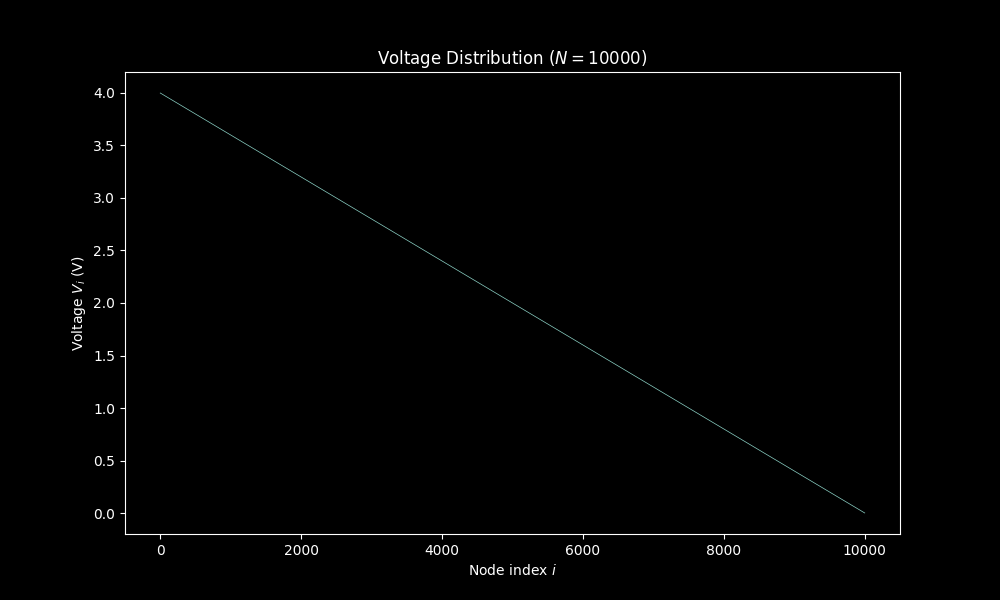

In [124]:
# 7.  

plt.figure(figsize=(10, 6))
plt.plot(range(1, N + 1), V, '-', linewidth=0.5)
plt.xlabel('Node index $i$')
plt.ylabel('Voltage $V_i$ (V)')
plt.title(f'Voltage Distribution ($N = {N}$)')
plt.show()

**ANS:**

VOltage falls linearly from V0 = 4 to 0. 

## Task 5: Eigensystems

### Background

Many physics problems reduce to finding eigenvalues $\lambda$ and eigenvectors x satisfying $Ax = \lambda x$. In principle one solves $\det(A - \lambda I) = 0$, but Python uses optimised matrix diagonalisation:

- `la.eig(A)` — general-purpose (any square matrix)
- `la.eigh(A)` — real symmetric / Hermitian (faster, always real eigenvalues)
- `la.eigvals(A)` — eigenvalues only


In [125]:
# 1. 

A8 = np.random.random((8, 8))
print('Random 8x8 matrix A8:\n', A8)

Random 8x8 matrix A8:
 [[0.96512183 0.12265416 0.39618948 0.02375087 0.36347971 0.36867287
  0.89741844 0.42748984]
 [0.08490056 0.45681664 0.97062413 0.71013229 0.09275084 0.68249701
  0.54587595 0.98265503]
 [0.18602033 0.63034494 0.22445879 0.92961725 0.51598436 0.75648063
  0.48991159 0.16453687]
 [0.30084559 0.60301118 0.28545272 0.05687466 0.69360625 0.16990075
  0.81964098 0.96620055]
 [0.26277654 0.25723715 0.44332893 0.03851801 0.83678539 0.59572075
  0.70297226 0.19977646]
 [0.36754221 0.6302574  0.23845515 0.94595255 0.47943734 0.40204053
  0.06326877 0.21498436]
 [0.0666807  0.46916706 0.68635744 0.69870062 0.17976734 0.50351949
  0.58579842 0.71992215]
 [0.3462658  0.14755716 0.03797502 0.95464915 0.43220347 0.1895624
  0.88900855 0.95081884]]


In [126]:
# 2. 

char_poly = np.poly(A8)
print('Characteristic polynomial coefficients:')
print(char_poly)

Characteristic polynomial coefficients:
[ 1.         -4.4787151   2.04227952  1.79155274  0.35150788 -1.55907801
  0.46598875  0.06275438 -0.04587791]


In [127]:
# 3. 

roots_eigs = np.roots(char_poly)

print('Eigenvalues:')
for i, e in enumerate(roots_eigs):
    print(f'  lambda_{i} = {e}')

Eigenvalues:
  lambda_0 = (3.8221816687138865+0j)
  lambda_1 = (-0.5717928833944219+0.4964943993903139j)
  lambda_2 = (-0.5717928833944219-0.4964943993903139j)
  lambda_3 = (0.7975463057054815+0j)
  lambda_4 = (0.6454207018605541+0j)
  lambda_5 = (0.3113008222172994+0.23722508076216622j)
  lambda_6 = (0.3113008222172994-0.23722508076216622j)
  lambda_7 = (-0.2654494587311157+0j)



#### 4. Eigenvalues `la.eigvals` (Direct Solve)

In [128]:
la_eigs = la.eigvals(A8)
for i, e in enumerate(la_eigs):
    print(f'  lambda_{i} = {e}')


  lambda_0 = (3.822181668713884+0j)
  lambda_1 = (-0.5717928833944221+0.4964943993903142j)
  lambda_2 = (-0.5717928833944221-0.4964943993903142j)
  lambda_3 = (0.7975463057054851+0j)
  lambda_4 = (0.6454207018605511+0j)
  lambda_5 = (0.3113008222172997+0.2372250807621666j)
  lambda_6 = (0.3113008222172997-0.2372250807621666j)
  lambda_7 = (-0.2654494587311154+0j)


ANS: The orders are jumbled but yes they agree

## Task 6: Eigenvalue Application — Gaussian Network Model

### Normal Modes of the HIV Reverse Transcriptase Protein

The **Gaussian Network Model (GNM)**  Normal modes are the eigenvalues/eigenvectors of the **Kirchhoff matrix** $\Gamma$:

$$\Gamma_{i,j} = \begin{cases}-1 & r_{i,j} < r_c \\ 0 & \text{otherwise}\end{cases},\quad \Gamma_{i,i} = -\sum_{j\neq i}\Gamma_{i,j}$$

Low-frequency modes = large-amplitude, biologically relevant collective motions.




**Notes:**

I learnt that Motion of Protein can be look at like their Chained Masses with springs between, like the ones we looked at in Mechanics Courses and Waves Courses. 


In [129]:
# 1. 

%matplotlib widget

In [130]:
# 2. 
data_file = '1rev_CAs.txt'
# Contains (x,y,z) pos of main backbone carbon atom


In [131]:
# 3. 

pos_array = np.genfromtxt(data_file,delimiter=',')
type(pos_array[1][0])
pos_array[0]

array([ 15.301, -57.62 ,  36.243])

In [132]:
# 4. 

print('Number of backbone Carbon atoms:', len(pos_array))
pos_array[:][0]

Number of backbone Carbon atoms: 936


array([ 15.301, -57.62 ,  36.243])

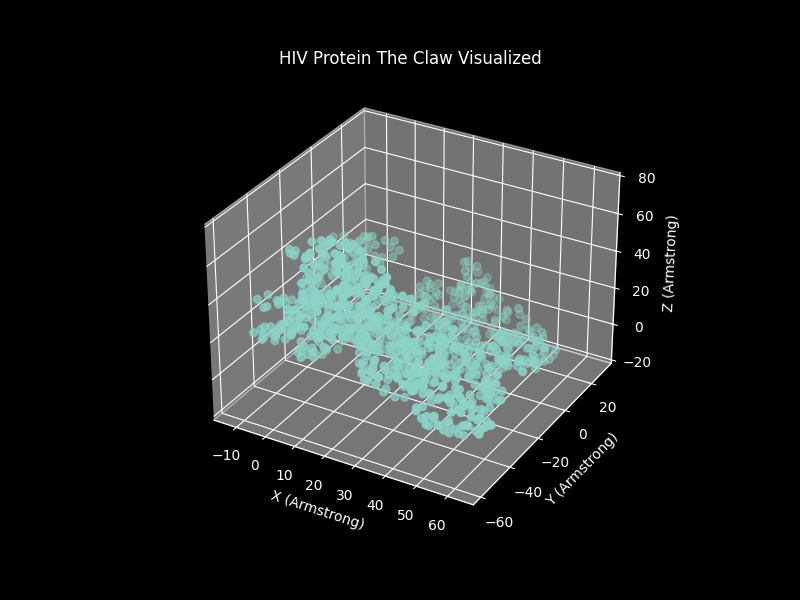

In [133]:
# 5. 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos_array[:,0], pos_array[:,1], pos_array[:,2],s=30 )
ax.set_xlabel('X (Armstrong)')
ax.set_ylabel('Y (Armstrong)')
ax.set_zlabel('Z (Armstrong)')
ax.set_title('HIV Protein The Claw Visualized')
plt.savefig('guide6_protein_structure.png', dpi=100)
plt.show()


I see a spot on the yz plane where there is a G like shape, this is the active side for the protein where the binding takes place.

In [134]:
# 6. 

# We did something like this ina  previous Gudide, to find the derevatives

N = len(pos_array)
dist_matrix = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        diff = pos_array[i] - pos_array[j]        # [dx, dy, dz]
        dist_matrix[i, j] = np.sqrt(np.sum(diff**2))

In [135]:
# 7. 

r_c = 7.0  # Angstroms

# Initialize Kirchhoff matrix
T = np.zeros((N, N)) # All zeros default

# off-diagonal elements
for i in range(N):
    for j in range(N):
        if i != j and dist_matrix[i, j] < r_c:
            T[i, j] = -1

# diagonal elements (negative row sum)
for i in range(N):
    T[i, i] = -np.sum(T[i, :])  # = number of contacts for atom i ?? # I am not sure about this one...
    

In [136]:
# 8.  

# la.eigh: Gamma is real symmetric, returns real eigenvalues in ascending order
eigenvalues, eigenvectors = la.eigh(T)
print('Eigenvalues shape:', eigenvalues.shape)
print('Eigenvectors shape:', eigenvectors.shape)

Eigenvalues shape: (936,)
Eigenvectors shape: (936, 936)


In [137]:
print('First 5 eigenvalues:')
for i in range(5):
    print(f'  lambda_{i} = {eigenvalues[i]}')

First 5 eigenvalues:
  lambda_0 = 7.706364671484509e-16
  lambda_1 = 0.01992772592186384
  lambda_2 = 0.03610670427768412
  lambda_3 = 0.03996319217839352
  lambda_4 = 0.09716253588794373


Yeah Mostly agress, the first one is Very small number, almost zero
 the rest are positive and increasing :)

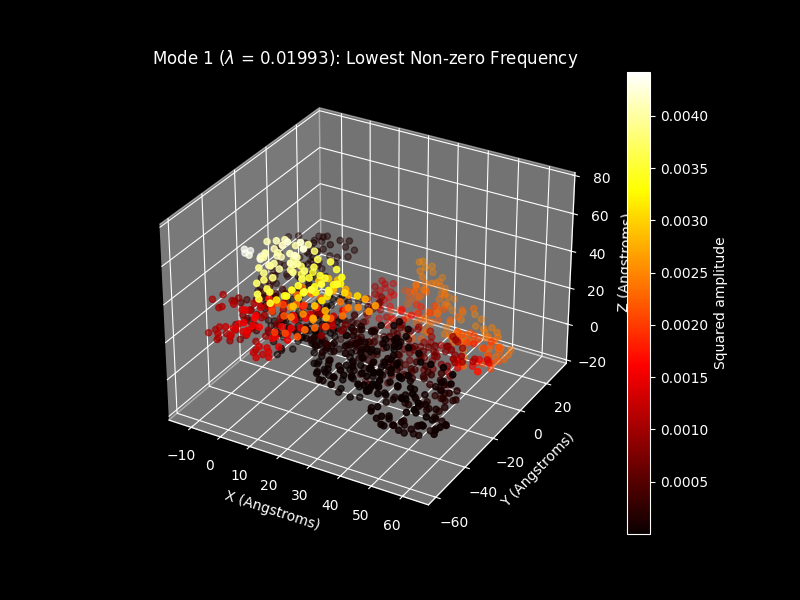

Saved mode 1 plot.


In [138]:
# 10. 3D scatter plot coloured by squared amplitudes of Mode 1 (lowest non-zero frequency)
mode1_idx = 1
mode1 = eigenvectors[:, mode1_idx]       # column = eigenvector
amplitude_sq_1 = mode1 ** 2             # squared amplitude at each atom

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pos_array[:, 0], pos_array[:, 1], pos_array[:, 2],
                c=amplitude_sq_1, cmap='hot', s=20)
plt.colorbar(sc, ax=ax, label='Squared amplitude')
ax.set_xlabel('X (Angstroms)')
ax.set_ylabel('Y (Angstroms)')
ax.set_zlabel('Z (Angstroms)')
ax.set_title(f'Mode 1 ($\\lambda$ = {eigenvalues[mode1_idx]:.5f}): Lowest Non-zero Frequency')
plt.savefig('guide6_mode1.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved mode 1 plot.')


#### 11. Analysis: 
*ANS:* The brightest (hottest/White coloured) atoms in the Mode 1 plot are those with the **largest squared amplitudes** — they move the most in the lowest-frequency Vibration. Here they are near the Clamps.

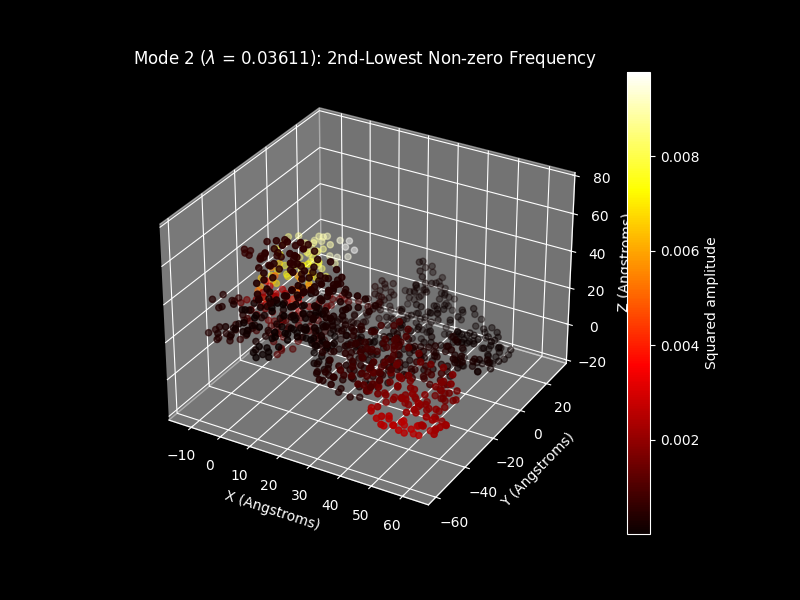

Saved mode 2 plot.


In [139]:
# 12. 3D scatter plot coloured by squared amplitudes of the 2nd-lowest non-zero frequency eigenvector (Mode 2)
mode2_idx = 2
mode2 = eigenvectors[:, mode2_idx]
amplitude_sq_2 = mode2 ** 2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pos_array[:, 0], pos_array[:, 1], pos_array[:, 2],
                c=amplitude_sq_2, cmap='hot', s=20)
plt.colorbar(sc, ax=ax, label='Squared amplitude')
ax.set_xlabel('X (Angstroms)')
ax.set_ylabel('Y (Angstroms)')
ax.set_zlabel('Z (Angstroms)')
ax.set_title(f'Mode 2 ($\\lambda$ = {eigenvalues[mode2_idx]:.5f}): 2nd-Lowest Non-zero Frequency')
plt.savefig('guide6_mode2.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved mode 2 plot.')

#### 13. Analysis:

*ANS:* Normal-mode analysis (NMA) decomposes the motions into orthogonal vectors . The lowest-frequency modes shows the **largest-amplitude motions**.

By mapping the squared amplitudes of each mode onto the 3D protein structure, we immediately identify The claw active site.

Apparenlty this insight would require expensive molecular dynamics simulations.

Ahilan's Note: It is cool how knowing 3D positions of atoms and applying a spring model can predict biological motions of protein. 

## Task 7: Wrap Up

The guide was overall clear and well-paced.

- **Task 6: I found it a bit difficult to connect the Last Protein content to what we did in the start, maybe more backgorund would have been nice.


- Nice Notebook: It was cool that I got to see Kichoff Current and Proteins in the Assignemnt. 